# HOUSE PRICE PREDICTION

## Import and Settings

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
from scipy.stats.mstats import winsorize
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.feature_selection import RFE
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "house_price_50k.csv"
RANDOM_STATE = 42
pd.options.display.float_format = '{:,.2f}'.format

## Load and audit the data

In [3]:
house = pd.read_csv(DATA_PATH)
house.head()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level,price
0,1360,6,2,2,9,10,0,0,1,0,1,0,1,0,6.94,7242,premium,low,"595,249.35"
1,4272,5,2,3,24,8,1,0,0,1,1,1,1,0,0.40,7729,low,low,"1,571,208.09"
2,3592,1,4,3,4,20,0,1,1,1,0,1,0,1,6.29,1081,premium,mid,"1,379,942.63"
3,966,5,2,2,6,14,1,0,0,0,0,1,1,0,8.96,8912,medium,low,"436,781.88"
4,4926,4,3,1,18,9,0,0,0,0,1,0,1,1,2.84,8146,low,mid,"1,792,424.71"


In [4]:
house.shape

(50000, 19)

In [5]:
house.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  50000 non-null  int64  
 1   bedrooms              50000 non-null  int64  
 2   bathrooms             50000 non-null  int64  
 3   floors                50000 non-null  int64  
 4   age                   50000 non-null  int64  
 5   distance              50000 non-null  int64  
 6   garage                50000 non-null  int64  
 7   parking               50000 non-null  int64  
 8   garden                50000 non-null  int64  
 9   security              50000 non-null  int64  
 10  school_nearby         50000 non-null  int64  
 11  hospital_nearby       50000 non-null  int64  
 12  shopping_mall_nearby  50000 non-null  int64  
 13  public_transport      50000 non-null  int64  
 14  crime_rate            50000 non-null  float64
 15  population_density    50000 no

In [6]:
house.isna().sum()

area                    0
bedrooms                0
bathrooms               0
floors                  0
age                     0
distance                0
garage                  0
parking                 0
garden                  0
security                0
school_nearby           0
hospital_nearby         0
shopping_mall_nearby    0
public_transport        0
crime_rate              0
population_density      0
location                0
income_level            0
price                   0
dtype: int64

In [7]:
house.duplicated().sum()

np.int64(0)

### Insight

The dataset contains 5000 records, 19 columns, no duplicates, no missing values and the data type are corredctly represented. 
The dataset contains several groups of features used to predict house prices. **Property characteristics** include area (total house size in square feet), bedrooms, bathrooms, floors, and age, which describe the physical size and structure of the house. **Location and accessibility** features include distance, location, and public_transport, which describe where the property is located and how accessible it is.

**Property amenities** include garage, parking, garden, and security, representing the facilities and features available at the property. **Nearby facilities** include school_nearby, hospital_nearby, and shopping_mall_nearby, which indicate the availability of important services around the property. **Socio-economic factors** include crime_rate, population_density (population concentration in the area), and income_level, which describe the characteristics of the surrounding area. Finally, **price is the target variable**, representing the estimated house price that the model aims to predict.


In [8]:
house.describe()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,price
count,"50,000.00","50,000.00","50,000.00","50,000.00","50,000.00","50,000.00","50,000.00","50,000.00","50,000.00","50,000.00","50,000.00","50,000.00","50,000.00","50,000.00","50,000.00","50,000.00","50,000.00"
mean,"2,752.97",3.50,2.50,2.00,19.57,14.97,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,5.01,"5,065.95","1,030,260.94"
std,"1,297.15",1.71,1.12,0.82,11.55,8.36,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,2.88,"2,864.34","458,019.88"
min,500.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,"90,900.69"
25%,"1,630.00",2.00,1.00,1.00,10.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.52,"2,575.00","635,737.46"
50%,"2,756.00",3.00,2.00,2.00,20.00,15.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,5.02,"5,060.50","1,031,763.26"
75%,"3,872.00",5.00,3.00,3.00,30.00,22.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,7.48,"7,543.00","1,423,102.02"
max,"4,999.00",6.00,4.00,3.00,39.00,29.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,10.00,"9,999.00","1,996,474.39"


In [9]:
house["location"].unique()

<StringArray>
['premium', 'low', 'medium']
Length: 3, dtype: str

In [10]:
house["income_level"].unique()

<StringArray>
['low', 'mid', 'high']
Length: 3, dtype: str

In [11]:
# Detecting outliers
num_cols = house[['area', 'bedrooms', 'bathrooms', 'floors', 'age', 'distance', 'crime_rate',
       'population_density', 'price']]
num_cols.head()

,area,bedrooms,bathrooms,floors,age,distance,crime_rate,population_density,price
0,1360,6,2,2,9,10,6.94,7242,"595,249.35"
1,4272,5,2,3,24,8,0.40,7729,"1,571,208.09"
2,3592,1,4,3,4,20,6.29,1081,"1,379,942.63"
3,966,5,2,2,6,14,8.96,8912,"436,781.88"
4,4926,4,3,1,18,9,2.84,8146,"1,792,424.71"


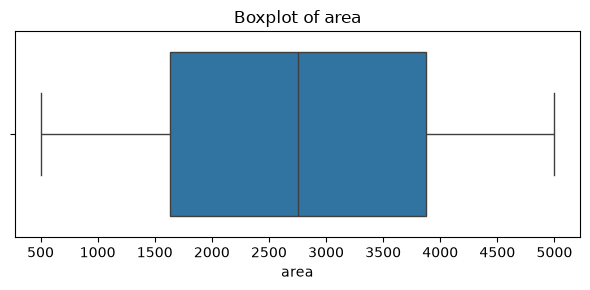

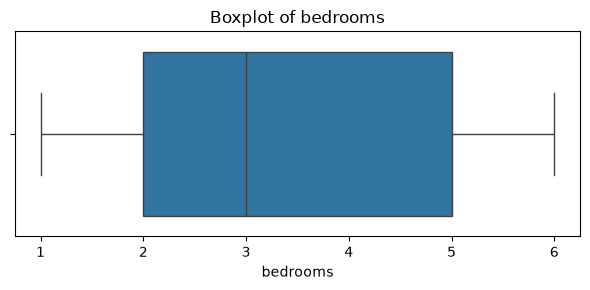

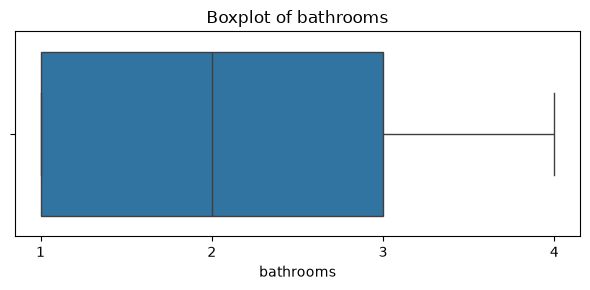

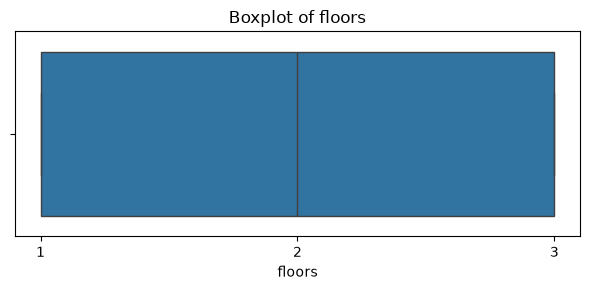

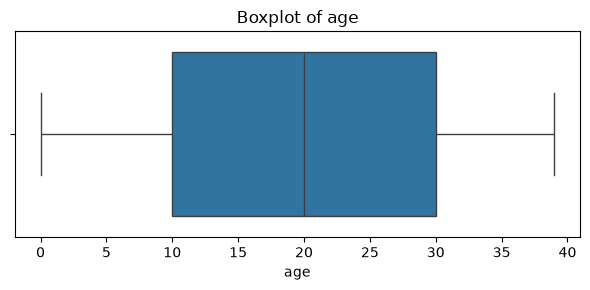

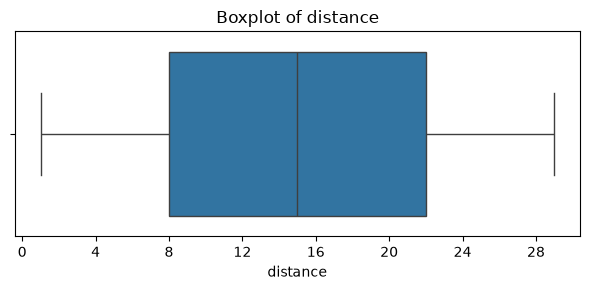

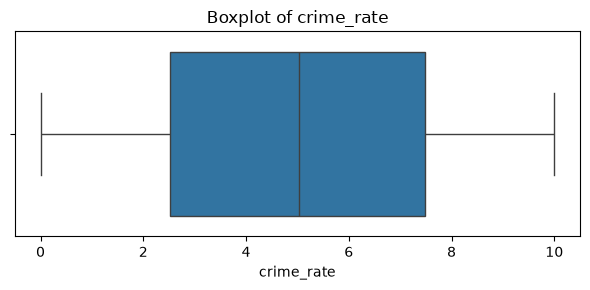

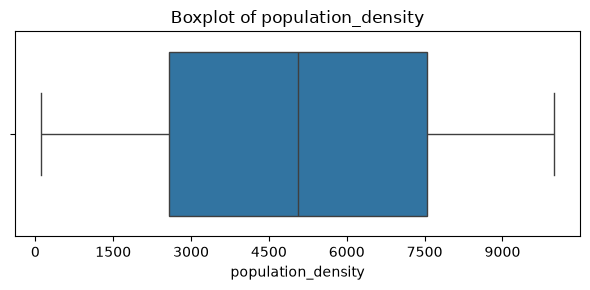

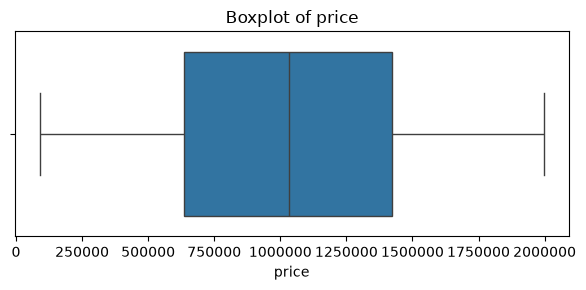

In [12]:
for col in num_cols:
    plt.figure(figsize = (6, 3))
    sns.boxplot(data = house, x = col)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    #  Turn off scientific notation (like 1e6) for large house prices
    plt.ticklabel_format(style='plain', axis='x')
    # This forces the x-axis to only use integer (whole number) ticks
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

## Report Narrative

* Property Area: Home sizes range from approximately 500 sq ft to 5,000 sq ft. The median area is 1,700 sq ft, with the majority of homes concentrated between 1,600 sq ft and 3,900 sq ft.
* Room Distribution: The number of bedrooms ranges from 1 to 6, with most homes containing between 2 and 5 rooms. Similarly, bathroom counts peak at 4, with the majority of properties featuring 1 to 3 bathrooms.
* Property Age: The housing stock shows a median age of 20 years. The majority of the properties are well-established, falling between 10 and 30 years old.
* Pricing Structure: Market prices range from a minimum of 100,000 to a maximum of 2,000,000. The median price sits at 1,050,000, and most homes are valued between 650,000 and 1,425,000. This specific dataset is perfectly symmetric and contains no extreme outliers.
* Geographic Distance: Property distances range from 1 to 29 units. The data is well-balanced with a median distance of 15 units, placing most homes between 8 and 22 units away from the reference point without any isolated outliers.
* There are no outliers. 

## EDA

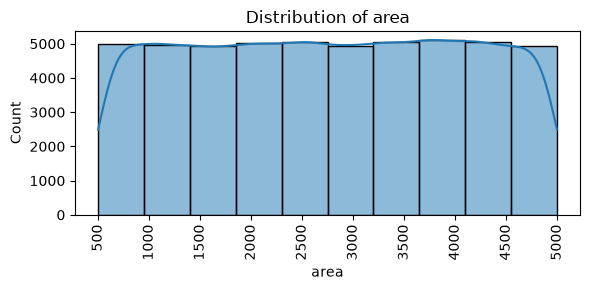

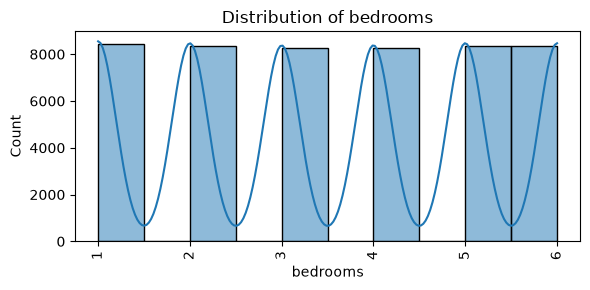

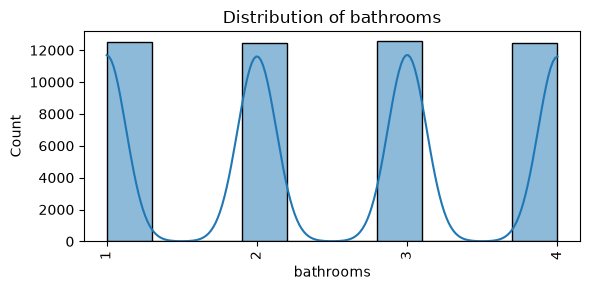

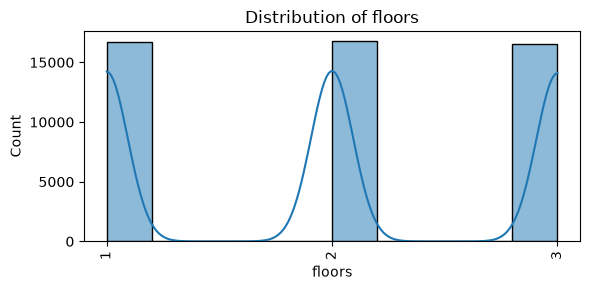

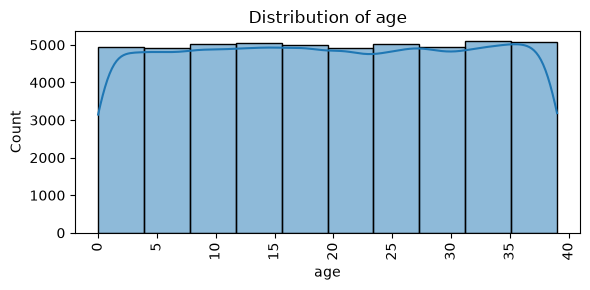

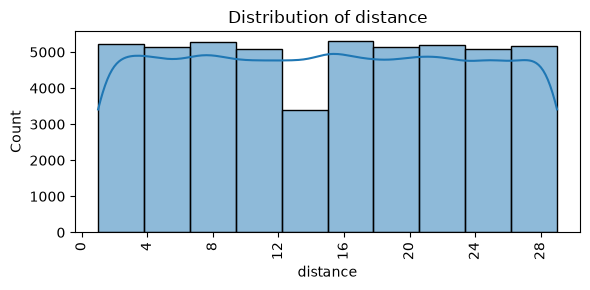

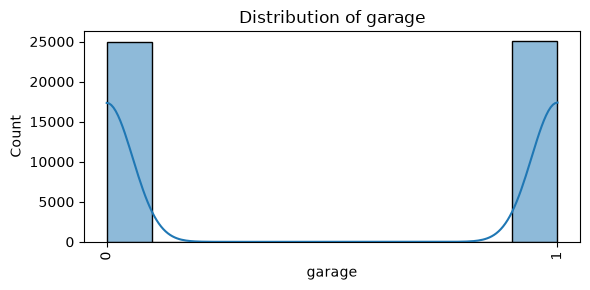

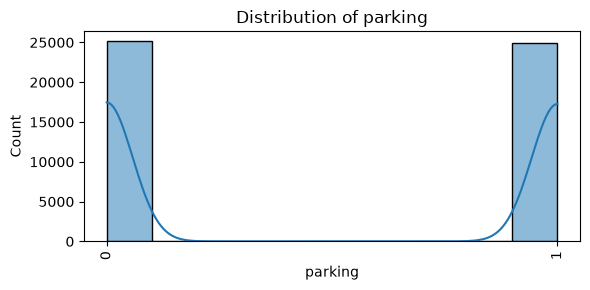

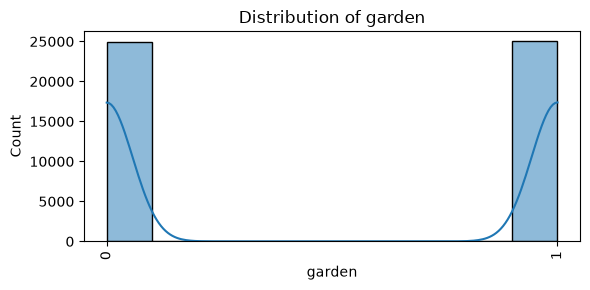

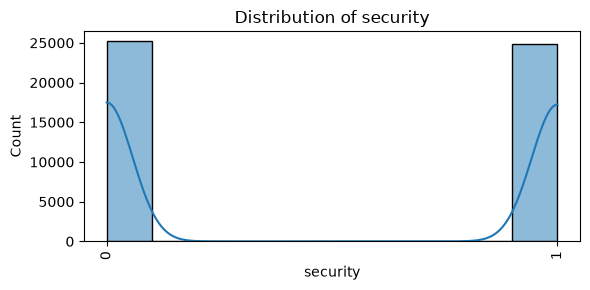

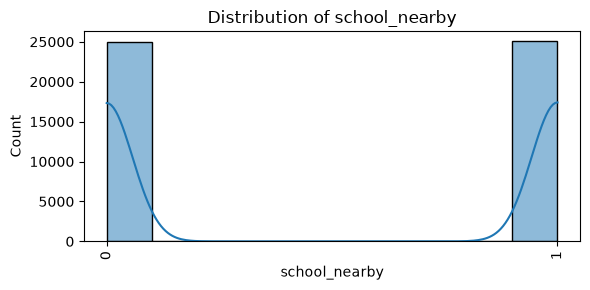

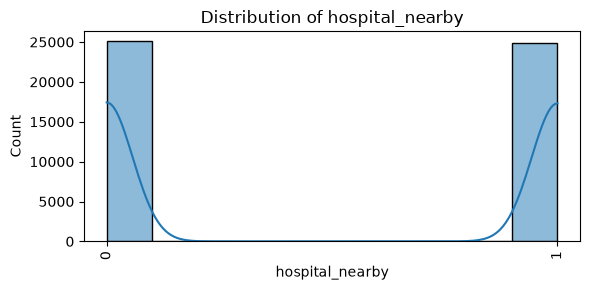

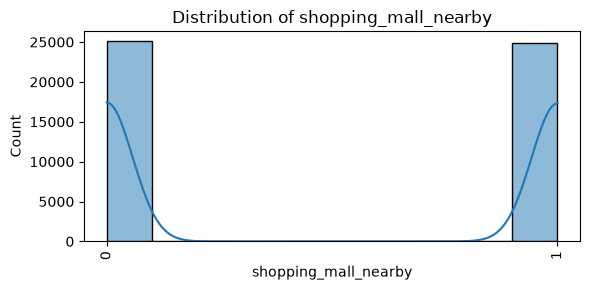

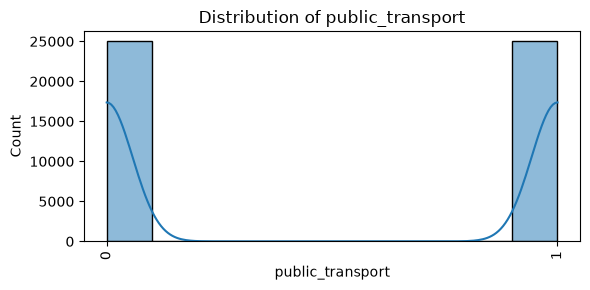

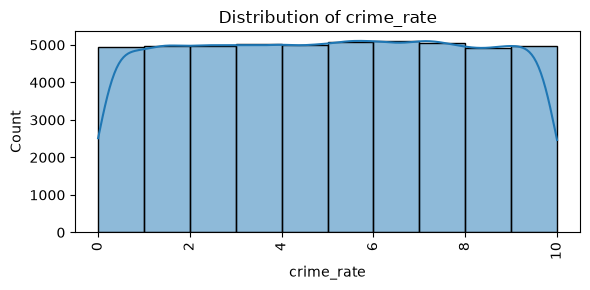

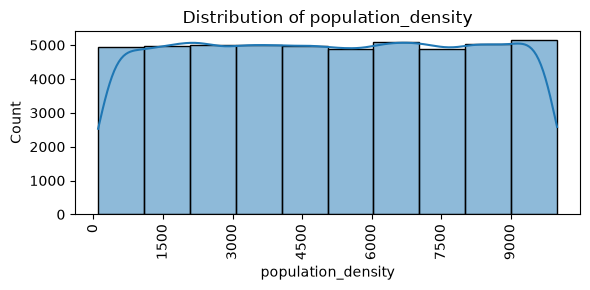

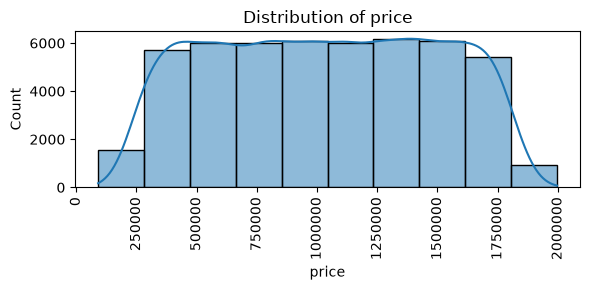

In [13]:
for col in house.select_dtypes(include = 'number'):
    plt.figure(figsize = (6, 3))
    sns.histplot(data = house, x = col, bins = 10, kde = True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    #  Turn off scientific notation (like 1e6) for large house prices
    plt.ticklabel_format(style='plain', axis='x')
    # This forces the x-axis to only use integer (whole number) ticks
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.xticks(rotation = 90)
    plt.tight_layout()
    plt.show()

### Insight
The housing dataset exhibits highly uniform distributions across all primary variables. Property distance, age, and area show completely flat frequencies. Most bins hold a steady 1,700 to 5,000 counts. House prices follow a symmetric, flat-topped shape. Price frequencies peak near 6,000 counts before tapering. This extreme balance suggests a highly standardized market profile.

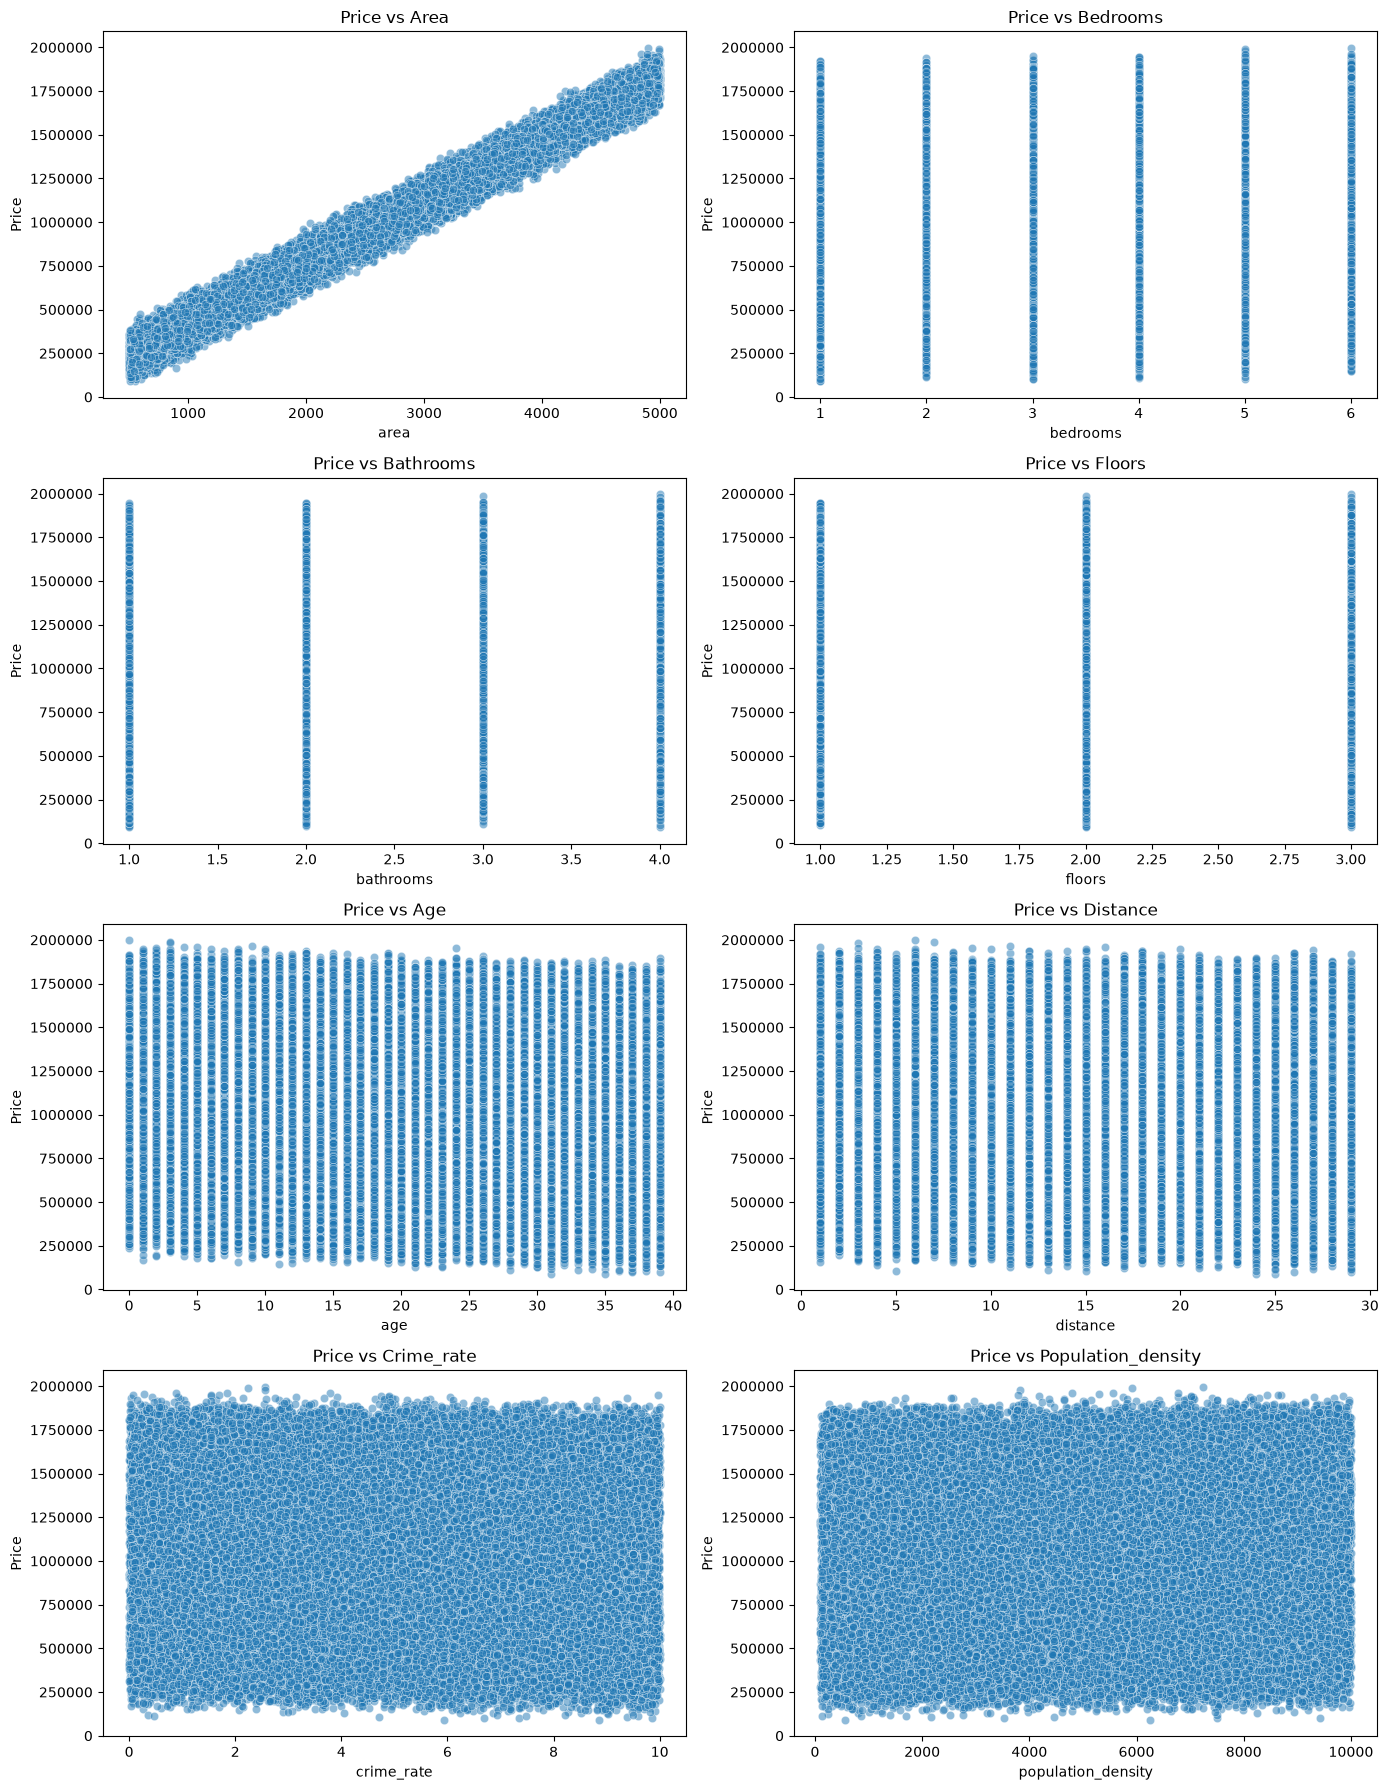

In [14]:
 # Creating subplots
target_cols = ['area', 'bedrooms', 'bathrooms', 'floors', 'age', 'distance', 'crime_rate', 'population_density']

fig, axes = plt.subplots(nrows = 4, ncols = 2, figsize = (14, 18))
axes = axes.flatten()
for i, col in enumerate(target_cols):
    sns.scatterplot(data = house, x = col, y = 'price', alpha = 0.5, ax = axes[i])
    axes[i].set_title(f'Price vs {col.capitalize()}')
    axes[i].set_ylabel('Price')
    axes[i].set_xlabel(col)
    axes[i].ticklabel_format(style = 'plain', axis='y')
plt.tight_layout()
plt.show()

### Insight:

Bivariate analysis reveals that property area is the sole driver of house prices in this dataset, exhibiting a near-perfect, strong positive linear correlation. As living space increases from 500 to 5,000 sq ft, house prices scale predictably from approximately 100,000 to 2,000,000. Conversely, all other features, including bedrooms, bathrooms, floors, age, distance, crime rate, and population density, display completely uniform vertical stripes or random clouds against the price axis, confirming zero correlation with property value and a complete absence of bivariate outliers.



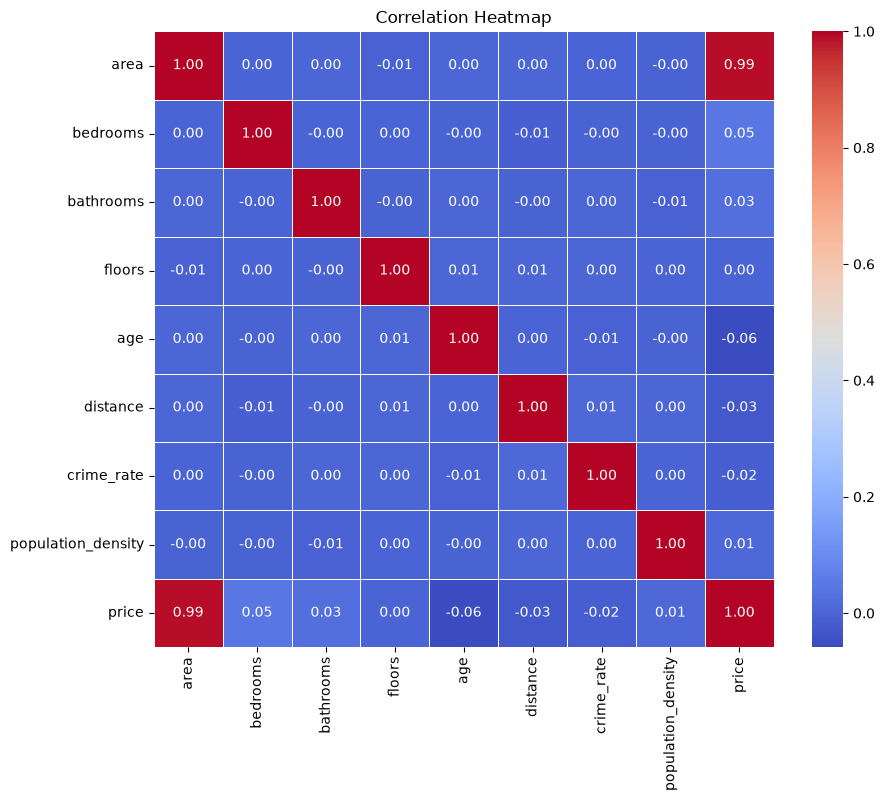

In [15]:
# Compute the correlation matrix
corr_matrix = num_cols.corr()

# Generate the heatmap
plt.figure(figsize = (10, 8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f", linewidths = 0.5)
plt.title('Correlation Heatmap')
plt.show()

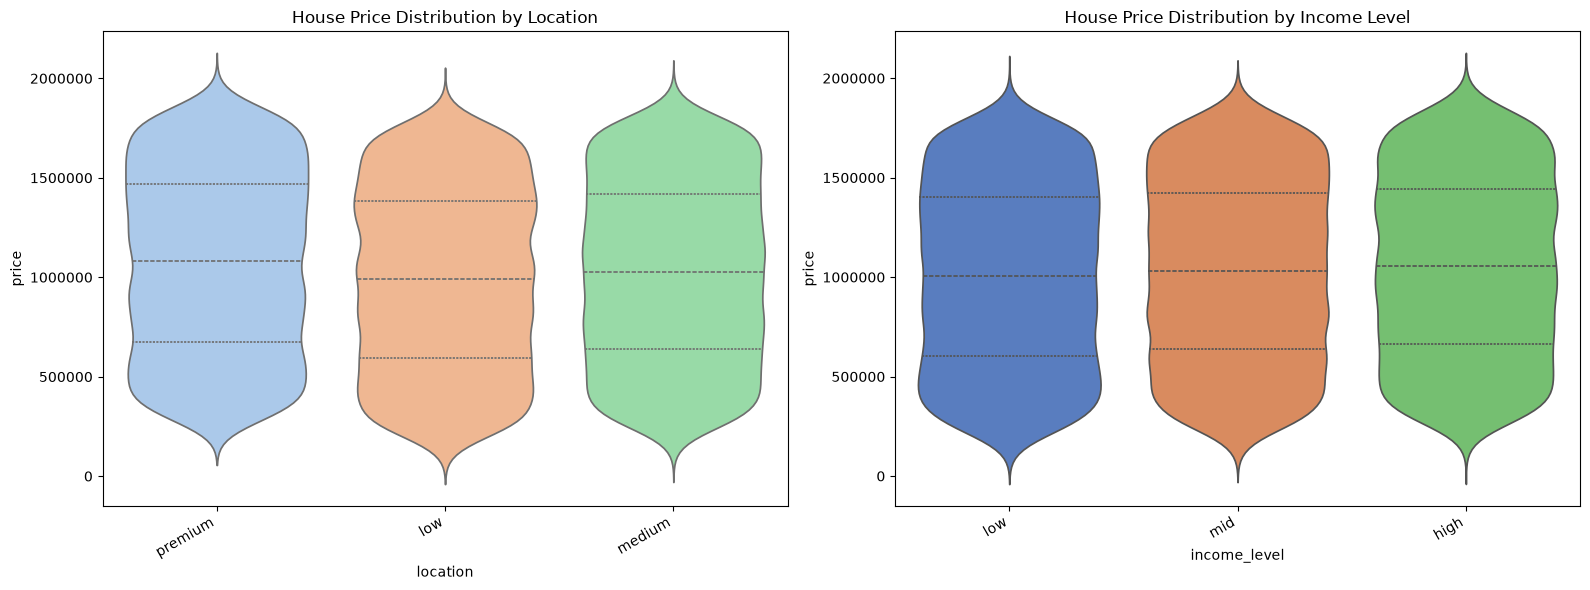

In [16]:
fig, axes = plt.subplots(nrows = 1, ncols=2, figsize=(16, 6))

# Plot 1: Price vs Location
sns.violinplot(data = house, x = 'location', y = 'price', palette = 'pastel', inner = 'quartile', ax = axes[0])
axes[0].set_title('House Price Distribution by Location')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation = 30, ha ='right')
axes[0].ticklabel_format(style = 'plain', axis = 'y')
# Plot 2: Price vs Income Level
sns.violinplot(data=house, x='income_level', y = 'price', palette = 'muted', inner = 'quartile', ax = axes[1])
axes[1].set_title('House Price Distribution by Income Level')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation = 30, ha = 'right')
axes[1].ticklabel_format(style = 'plain', axis = 'y')
plt.tight_layout()
plt.show()


### Insight:
The generated violin plots show that house prices are identically distributed across all categories of location and income level, indicating that neither variable has any relationship with property price.

### Split

In [17]:
X = house.drop(columns = "price")
y = house["price"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = RANDOM_STATE)
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (40000, 18) (40000,)
Test: (10000, 18) (10000,)


In [19]:
categorical_col = X_train.select_dtypes(include = ["object"]).columns
numerical_col = X_train.select_dtypes(include = ["int64", "float64"]).columns

### Preprocessing and Feature Selection

In [20]:
def preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), numerical_col),
        ("cat", OneHotEncoder(drop = "first", handle_unknown = "ignore"), categorical_col)
    ])

In [21]:
models = {
    "All features": Pipeline([("prep", preprocessor()), ("model", LinearRegression())]),
    "top_10_features": Pipeline([("prep", preprocessor()), ("rfe", RFE(LinearRegression(), n_features_to_select = 10)),
                                                            ("model", LinearRegression())]) 
}

In [22]:
cv = KFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)
scoring_metrics = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}

rows = []
for model_name, pipe in models.items():
    cv_scores =  cross_validate(pipe, X_train, y_train, cv = cv, scoring = scoring_metrics)
    rows.append({
        "model": model_name, 
        "rmse": -cv_scores["test_rmse"].mean(),
        "mae": -cv_scores["test_mae"].mean(),
        "r2": cv_scores["test_r2"].mean()
    })

In [23]:
cv_results = (pd.DataFrame(rows).set_index("model").sort_values("rmse"))
print(cv_results.round(4))

                     rmse       mae   r2
model                                   
All features    20,014.28 15,982.26 1.00
top_10_features 21,766.78 17,384.47 1.00


In [24]:
best_model = cv_results.index[0]
print("Best Model:", best_model)

Best Model: All features


In [25]:
top10_pipe = models["top_10_features"]
top10_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('rfe', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['area','bedrooms','bathrooms',...,'population_density','location', 'income_level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of 

In [26]:
feature_names = top10_pipe["prep"].get_feature_names_out()
rfe = top10_pipe["rfe"]
selected_features = feature_names[rfe.support_]
print("Selected 10 features:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

Selected 10 features:
1. num__area
2. num__bedrooms
3. num__bathrooms
4. num__age
5. num__distance
6. num__crime_rate
7. cat__location_medium
8. cat__location_premium
9. cat__income_level_low
10. cat__income_level_mid


In [27]:
final_model = models[best_model]
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['area','bedrooms','bathrooms',...,'population_density','location', 'income_level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of col

In [28]:
y_pred = final_model.predict(X_test)

In [29]:
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [30]:
print(f"RMSE: {rmse:.3f}")
print(f"MSE: {mse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")

RMSE: 19940.849
MSE: 397637450.315
MAE: 15954.173
R2: 0.998


In [31]:
y_max_20 = 0.2 * y.max()
y_max_20 = y_max_20.round(2)
y_max_20

np.float64(399294.88)

In [32]:
rmse < y_max_20

np.True_

Root mean squared error must be less than 20% of the price. 

### CHECKING ASSUMPTIONS

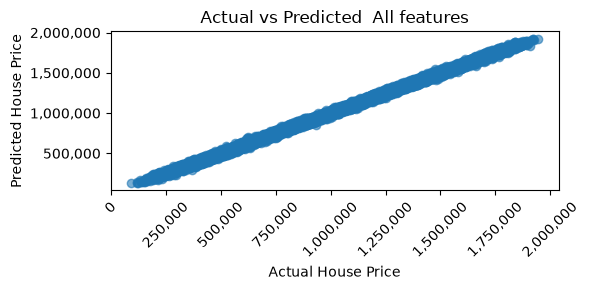

In [33]:
plt.figure(figsize=(6, 3))
plt.scatter(y_test, y_pred, alpha = 0.6)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title(f"Actual vs Predicted  {best_model}")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Residual Plot')

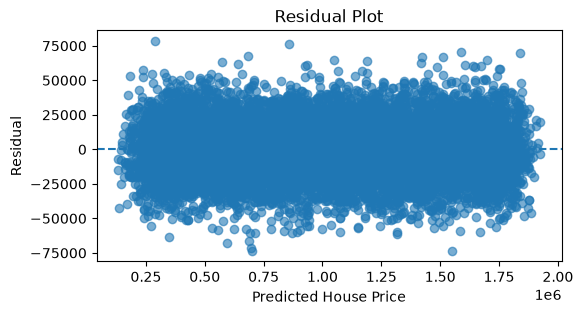

In [34]:
# Redidual must not have a pattern
residuals = y_test - y_pred
plt.figure(figsize = (6, 3))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted House Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

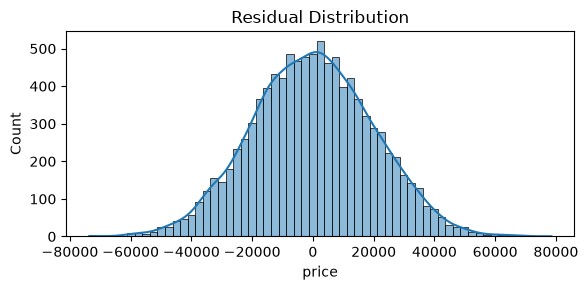

In [35]:
# Redidual must be normally distributed.
plt.figure(figsize = (6, 3))
sns.histplot(residuals, kde = True)
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

### Insight:

The diagnostic plots show that the regression model performs very well and meets the main linear regression assumptions. The **Actual vs. Predicted** plot shows that the predicted values are close to the actual values. The **Residual Plot** shows a random pattern, suggesting that the errors have a fairly constant spread (**homoscedasticity**).

The **Residual Distribution** is roughly bell-shaped and centered around zero, which suggests that the prediction errors are approximately normally distributed. Overall, the plots indicate that the model fits the data well, with no major problems or unusual patterns in the errors.


### COEFFICIENT ANALYSIS

In [36]:
feature_name = final_model["prep"].get_feature_names_out()
coefficient = final_model["model"].coef_
df = pd.DataFrame({
    "features": feature_name, 
    "Coef": coefficient
})
df

,features,Coef
0,num__area,"454,026.97"
1,num__bedrooms,"20,502.29"
2,num__bathrooms,"10,161.05"
3,num__floors,"4,072.21"
4,num__age,"-28,938.05"
5,num__distance,"-14,988.11"
6,num__garage,"2,480.50"
7,num__parking,"2,392.14"
8,num__garden,"2,478.60"
9,num__security,"2,359.66"


In [37]:
df["abs_coef"] = df["Coef"].abs()
df = df.sort_values("abs_coef", ascending = False)
df.head()

,features,Coef,abs_coef
0,num__area,"454,026.97","454,026.97"
17,cat__location_premium,"80,256.43","80,256.43"
18,cat__income_level_low,"-50,077.17","50,077.17"
16,cat__location_medium,"40,240.01","40,240.01"
19,cat__income_level_mid,"-29,816.08","29,816.08"


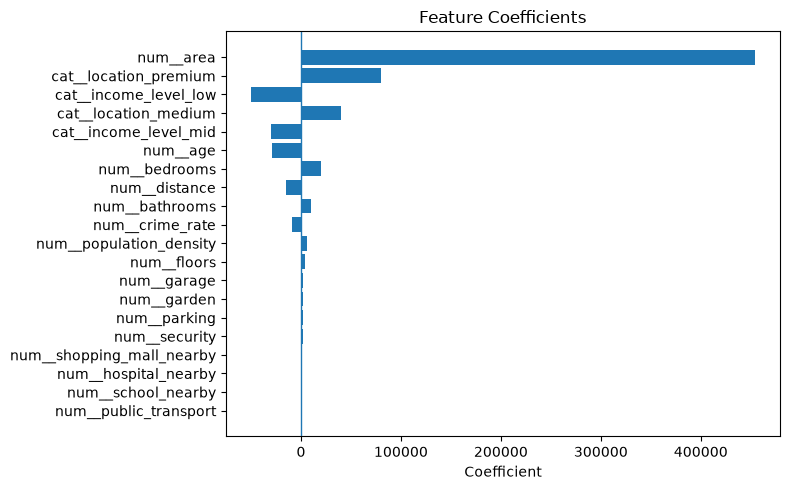

In [38]:
plt.figure(figsize = (8, 5))
plt.barh(df["features"], df["Coef"])
plt.axvline(0, linewidth = 1)
plt.xlabel("Coefficient")
plt.title("Feature Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This visualization displays feature importance for the model's prediction. Area has the largest positive impact, whereas income level is the leading negative driver.

In [39]:
ridge_model = Pipeline([("prep", preprocessor()), ("model", Ridge(alpha = 1.0))])
ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['area','bedrooms','bathrooms',...,'population_density','location', 'income_level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of col

In [40]:
ridge_y_pred = ridge_model.predict(X_test)

In [41]:
ridge_rmse = root_mean_squared_error(y_test, ridge_y_pred)
ridge_mse = mean_squared_error(y_test, ridge_y_pred)
ridge_mae = mean_absolute_error(y_test, ridge_y_pred)
ridge_r2 = r2_score(y_test, ridge_y_pred)

In [42]:
print(f"RMSE: {ridge_rmse:.3f}")
print(f"MSE: {ridge_mse:.3f}")
print(f"MAE: {ridge_mae:.3f}")
print(f"R²: {ridge_r2:.3f}")

RMSE: 19940.650
MSE: 397629516.386
MAE: 15954.039
R²: 0.998


### Compare Linear Regression and Ridge

In [43]:
comparison = pd.DataFrame({
    "Model" : ["Linear Regression", "Ridge"],
    "RMSE" : [rmse, ridge_rmse],
    "MSE" : [mse, ridge_mse],
    "MAE" : [mae, ridge_mae],
    "R2" : [r2, ridge_r2]
})
comparison

,Model,RMSE,MSE,MAE,R2
0,Linear Regression,"19,940.85","397,637,450.32","15,954.17",1.00
1,Ridge,"19,940.65","397,629,516.39","15,954.04",1.00


In [44]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_cv = Pipeline([
    ("prep", preprocessor()), 
    ("ridge_cv_model", RidgeCV(alphas = alphas, cv = 5))
])
ridge_cv.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('ridge_cv_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['area','bedrooms','bathrooms',...,'population_density','location', 'income_level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subs

In [45]:
print("Best Alpha", ridge_cv["ridge_cv_model"].alpha_)

Best Alpha 0.1


In [46]:
ridge_predictions = ridge_cv.predict(X_test)

In [47]:
ridge_cv_rmse = root_mean_squared_error(y_test, ridge_predictions)
ridge_cv_mse = mean_squared_error(y_test, ridge_predictions)
ridge_cv_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_cv_r2 = r2_score(y_test, ridge_predictions)

print(f"RMSE: {ridge_rmse:,.3f}")
print(f"MSE: {ridge_mse:,.3f}")
print(f"MAE: {ridge_mae:,.3f}")
print(f"R²: {ridge_r2:.3}")

RMSE: 19,940.650
MSE: 397,629,516.386
MAE: 15,954.039
R²: 0.998


### Compare Linear regression, Ridge and RidgeCV

In [48]:
comparison = pd.DataFrame({
    "Model" : ["Linear Regression", "Ridge", "RidgeCV"],
    "RMSE" : [rmse, ridge_rmse, ridge_cv_rmse],
    "MSE" : [mse, ridge_mse, ridge_cv_mse],
    "MAE" : [mae, ridge_mae, ridge_cv_mae],
    "R2" : [r2, ridge_r2, ridge_cv_r2]
})
comparison

,Model,RMSE,MSE,MAE,R2
0,Linear Regression,"19,940.85","397,637,450.32","15,954.17",1.00
1,Ridge,"19,940.65","397,629,516.39","15,954.04",1.00
2,RidgeCV,"19,940.83","397,636,639.56","15,954.16",1.00


The three models show almost identical performance, with RMSE around 19,941, MAE around 15,954, and R² of 1.00. Ridge achieves the slightly lowest RMSE, MSE, and MAE, but the differences are negligible, while RidgeCV also provides no meaningful improvement over Linear Regression. Overall, regularization has very little impact on predictive performance for this dataset.
